# Credit Risk Modeling: Probability of Default

This notebook starts a practical credit risk modeling workflow using the Give Me Some Credit dataset. The objective is to estimate borrower probability of default (PD), a core quantity in credit risk because it summarizes the likelihood that a borrower becomes seriously delinquent over a defined horizon.

We will compare an interpretable logistic regression baseline with an XGBoost benchmark, then evaluate the models using ranking metrics, probability calibration, and risk-bucket analysis.

## Data Loading

The next step will load the raw training data from the local `data/` directory and inspect the target variable, missing values, and borrower-level risk features.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))

from load_data import (
    TARGET_COL,
    TRAIN_DATA_PATH,
    fit_missing_value_preprocessor,
    load_training_data,
    make_train_val_split,
    prepare_features_target,
    summarize_missing_values,
)

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.float_format", "{:.4f}".format)

In [2]:
df = load_training_data()

df.shape

(150000, 12)

In [3]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.7661,45,2,0.8030,9120.0000,13,0,6,0,2.0000
1,2,0,0.9572,40,0,0.1219,2600.0000,4,0,0,0,1.0000
2,3,0,0.6582,38,1,0.0851,3042.0000,2,1,0,0,0.0000
3,4,0,0.2338,30,0,0.0360,3300.0000,5,0,0,0,0.0000
4,5,0,0.9072,49,1,0.0249,63588.0000,7,0,1,0,0.0000


## Target And Missing Values

The target marks borrowers who became seriously delinquent within two years. Missing values are treated as model inputs carefully: imputation values are fitted only on the training split, and missingness indicators are added because absent income or dependent information may itself carry risk signal.

In [4]:
target_rate = df["SeriousDlqin2yrs"].mean()

pd.DataFrame(
    {
        "count": df["SeriousDlqin2yrs"].value_counts().sort_index(),
        "share": df["SeriousDlqin2yrs"].value_counts(normalize=True).sort_index(),
    }
).rename(index={0: "No serious delinquency", 1: "Serious delinquency"})

,count,share
No serious delinquency,139974,0.9332
Serious delinquency,10026,0.0668


In [5]:
summarize_missing_values(df)

,missing_count,missing_rate
MonthlyIncome,29731,0.1982
NumberOfDependents,3924,0.0262


## Exploratory Visuals

The first plots focus on model-relevant structure: class imbalance, missing data, feature distributions, and how observed delinquency changes across simple feature buckets.

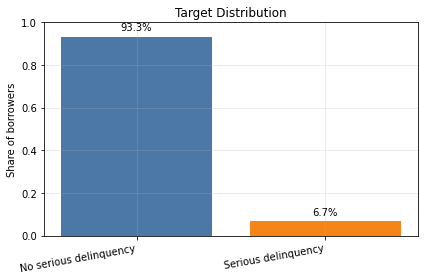

In [6]:
target_summary = df[TARGET_COL].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ["No serious delinquency", "Serious delinquency"],
    target_summary.values,
    color=["#4C78A8", "#F58518"],
)

ax.set_title("Target Distribution")
ax.set_ylabel("Share of borrowers")
ax.set_ylim(0, 1)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.1%}",
        ha="center",
        va="bottom",
    )

plt.xticks(rotation=10, ha="right")
plt.tight_layout()

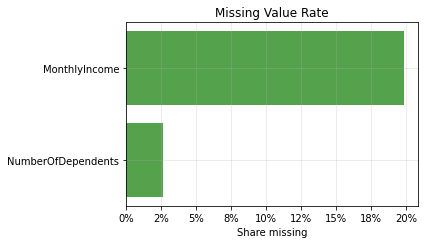

In [7]:
missing_summary = summarize_missing_values(df)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.barh(
    missing_summary.index,
    missing_summary["missing_rate"],
    color="#54A24B",
)
ax.set_title("Missing Value Rate")
ax.set_xlabel("Share missing")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
ax.invert_yaxis()

plt.tight_layout()

Several borrower variables are strongly right-skewed. The histograms below clip each feature at its 99th percentile only for visualization, so extreme values do not compress the main distribution.

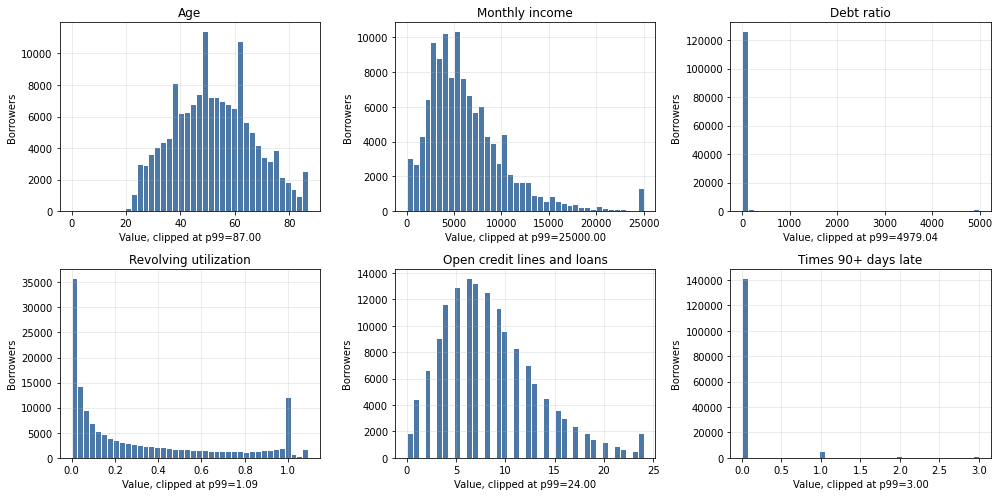

In [8]:
feature_labels = {
    "age": "Age",
    "MonthlyIncome": "Monthly income",
    "DebtRatio": "Debt ratio",
    "RevolvingUtilizationOfUnsecuredLines": "Revolving utilization",
    "NumberOfOpenCreditLinesAndLoans": "Open credit lines and loans",
    "NumberOfTimes90DaysLate": "Times 90+ days late",
}

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for ax, (feature, label) in zip(axes.ravel(), feature_labels.items()):
    values = df[feature].dropna()
    upper = values.quantile(0.99)
    clipped = values.clip(upper=upper)

    ax.hist(clipped, bins=40, color="#4C78A8", edgecolor="white")
    ax.set_title(label)
    ax.set_ylabel("Borrowers")
    ax.set_xlabel(f"Value, clipped at p99={upper:.2f}")

plt.tight_layout()

A simple feature-decile view helps show whether borrower characteristics are directionally related to observed default rates before fitting any model.

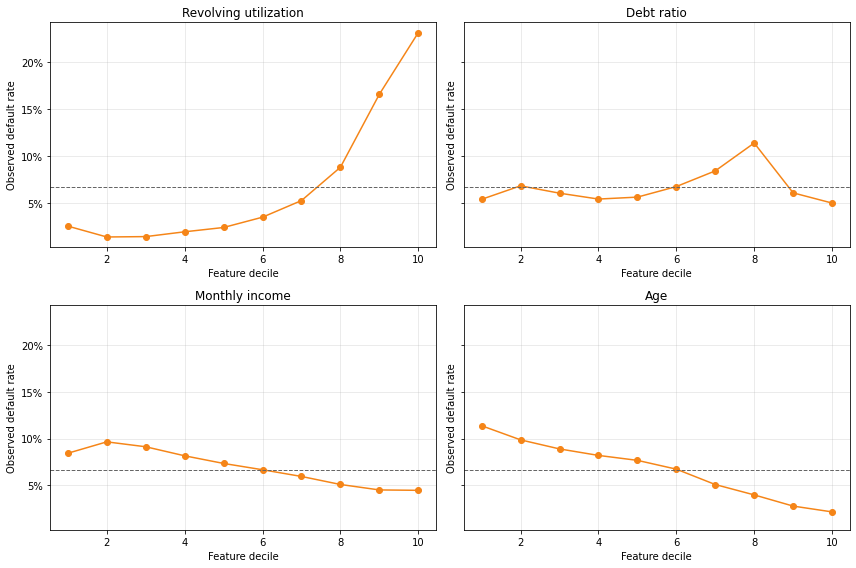

In [9]:
risk_features = {
    "RevolvingUtilizationOfUnsecuredLines": "Revolving utilization",
    "DebtRatio": "Debt ratio",
    "MonthlyIncome": "Monthly income",
    "age": "Age",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)

for ax, (feature, label) in zip(axes.ravel(), risk_features.items()):
    feature_data = df[[feature, TARGET_COL]].dropna().copy()
    feature_data["feature_decile"] = pd.qcut(
        feature_data[feature].rank(method="first"),
        q=10,
        labels=False,
    ) + 1

    default_by_decile = feature_data.groupby("feature_decile")[TARGET_COL].mean()

    ax.plot(default_by_decile.index, default_by_decile.values, marker="o", color="#F58518")
    ax.axhline(df[TARGET_COL].mean(), color="#666666", linestyle="--", linewidth=1)
    ax.set_title(label)
    ax.set_xlabel("Feature decile")
    ax.set_ylabel("Observed default rate")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))

plt.tight_layout()

## Train-Validation Split

The split is stratified so that the validation set preserves the default rate. Median imputation is then fitted on the training features and applied consistently to both training and validation features.

In [10]:
X, y = prepare_features_target(df)
X_train, X_val, y_train, y_val = make_train_val_split(X, y)

missing_preprocessor = fit_missing_value_preprocessor(X_train)
X_train_clean = missing_preprocessor.transform(X_train)
X_val_clean = missing_preprocessor.transform(X_val)

{
    "train_shape": X_train_clean.shape,
    "validation_shape": X_val_clean.shape,
    "missing_indicator_columns": missing_preprocessor.indicator_columns,
    "remaining_train_missing_values": int(X_train_clean.isna().sum().sum()),
    "remaining_validation_missing_values": int(X_val_clean.isna().sum().sum()),
}

{'train_shape': (120000, 12),
 'validation_shape': (30000, 12),
 'missing_indicator_columns': ['MonthlyIncome', 'NumberOfDependents'],
 'remaining_train_missing_values': 0,
 'remaining_validation_missing_values': 0}